In [1]:
import numpy as np
import pandas as pd
# import pyarrow.dataset as ds
import matplotlib.pyplot as plt
%matplotlib widget

SPHEREx official data now use `parquet` format, which can be read with `pandas`, though sometimes when data gets extremely large or if they are partitioned (by sky location), it might be better to use `pyarrow.dataset` to read it. With `pyarrow.dataset`, you can pre-load the columns, set up selection criteria and filtering before loading into memory. You can also batch-load a series of parquet files with pyarrow and load them into the same table.  

The `_gals.parq` catalog are selected only by `z_specz>0.001` and `_stars.parq` are with `z_specz<0.001` without any more criteria, so there could be lots of contaminations. 

In [2]:
filename = '../data/hotdog_l4_specz_collate_gals.parq'
dat = pd.read_parquet(filename)
dat

,SPHERExRefID,spherex_class,ra,dec,LS_z_mag_spherex_nat,WISE_W1_mag_spherex_nat,WISE_W2_mag_spherex_nat,LS_z_spherex_nat,WISE_W1_spherex_nat,WISE_W2_spherex_nat,...,2MASS_Ks_error,WISE_W1,WISE_W2,WISE_W1_error,WISE_W2_error,WISE_W3,WISE_W4,WISE_W3_error,WISE_W4_error,z_specz
0,1838385083292057605,32,4.198132,-3.614465,19.196869,18.602290,NaN,76.081457,131.555883,NaN,...,-9999.000000,83.868717,74.267704,2.780178,4.445120,367.451479,2318.462095,161.056081,-9999.000000,0.283411
1,1838385091445784579,32,4.222391,-3.616808,19.931632,NaN,NaN,38.669921,NaN,NaN,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.952847
2,1855976457587654665,32,2.128596,-4.199131,20.474384,19.414379,18.937305,23.457018,62.269385,96.628249,...,-9999.000000,48.842738,80.463700,2.338695,4.371416,388.686986,2537.464646,-9999.000000,-9999.000000,2.777576
3,1856257924058316800,2080,2.105211,-4.212510,17.900448,17.858028,18.402526,251.100186,261.104983,158.130579,...,65.224119,234.855102,147.095708,4.325140,4.469759,359.749335,2280.342072,-9999.000000,-9999.000000,0.176142
4,1856398678374219780,32,2.142618,-4.214779,20.735734,19.295860,NaN,18.438807,69.451585,NaN,...,-9999.000000,58.559856,34.897957,2.372591,4.209606,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.820158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322961,1456993370185400327,2080,21.795324,9.061753,18.239122,17.698080,18.222770,183.813533,302.547942,186.602858,...,-9999.000000,235.939144,166.111615,6.300401,5.200548,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.224849
322962,1457134090695213061,2080,21.758540,9.055362,18.801318,17.667787,18.815984,109.521426,311.108331,108.051984,...,-9999.000000,250.495541,163.230007,4.151860,4.509116,578.096047,3259.867889,159.695041,1167.669069,0.546377
322963,1458400753591779333,32,21.814516,9.012978,20.376666,20.693788,19.969586,25.666090,19.165099,37.341499,...,-9999.000000,18.638030,34.292567,2.231072,4.515504,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.676195
322964,1458400753860214785,2080,21.820147,9.010310,18.669685,18.535608,20.330764,123.638126,139.888808,26.774466,...,-9999.000000,104.423922,72.310273,2.980793,4.527715,420.726628,2251.127016,-9999.000000,-9999.000000,0.088834


In [3]:
list(dat.columns)

['SPHERExRefID',
 'spherex_class',
 'ra',
 'dec',
 'LS_z_mag_spherex_nat',
 'WISE_W1_mag_spherex_nat',
 'WISE_W2_mag_spherex_nat',
 'LS_z_spherex_nat',
 'WISE_W1_spherex_nat',
 'WISE_W2_spherex_nat',
 'Nsamples',
 'flux_dered_fiducial',
 'flux_err_dered_fiducial',
 'frac_sampled_306',
 'frac_sampled_102',
 'lambda_fiducial',
 'fiducial_flux',
 'fiducial_flux_err',
 'prob_gal',
 'z_best_gals',
 'z_err_std_gals',
 'z_err_l68_gals',
 'z_err_u68_gals',
 'minchi2_minchi2_gals',
 'z_minchi2_gals',
 'mod_minchi2_gals',
 'extlaw_minchi2_gals',
 'ebv_minchi2_gals',
 'scale_minchi2_gals',
 'z_pdfmax_gals',
 'minchi2_pdfmax_gals',
 'mod_pdfmax_gals',
 'extlaw_pdfmax_gals',
 'ebv_pdfmax_gals',
 'scale_pdfmax_gals',
 'z_best_agn',
 'z_err_std_agn',
 'z_err_l68_agn',
 'z_err_u68_agn',
 'minchi2_minchi2_agn',
 'z_minchi2_agn',
 'mod_minchi2_agn',
 'extlaw_minchi2_agn',
 'ebv_minchi2_agn',
 'scale_minchi2_agn',
 'z_pdfmax_agn',
 'minchi2_pdfmax_agn',
 'mod_pdfmax_agn',
 'extlaw_pdfmax_agn',
 'ebv_pdfm

Some of the columns are nested, meaning each entry itself is a python ndarray.
Each source is from a reference catalog (RefCat) so they mostly have external photometry. For us, some important/useful columns are:  

| Column name    | description    |
| --- | --- |
| `SPHERExRefID` | the unique ID number  |  
| `flux_dered_fiducial` |  binned (306) and de-reddened (correction from galactic extinction) fiducial fluxes [uJy]  |
|`flux_err_dered_fiducial` | binned and de-reddened (correction from galactic extinction) fiducial flux uncertainties [uJy]  |
|`fiducial_flux` | binned (102) and de-reddened(?) fluxes [uJy] |
|`fiducial_flux_err` | binned (102) and de-reddened(?) flux uncertainties [uJy] |
|`lambda_fiducial` | binned wavelength points (ALL objects should have the same lambdea_fiducial)  |
|`z_specz` | spectroscopic redshift  |
|`fiducial_flux` | binned to 102 fiducial fluxes |

### Important:
When there are no primary fluxes in a bin, SPHEREx team set the flux=0 and error=50000.  
For all-sky sources, ~2/3 of 306 fiducial bins will probably be zero, because it has only been covered by survey 102 times.  
Each of the sources will have slightly different usable wavelength points, and we should check `frac_sampled_102` for coverage.


Some useful ones that we may or may not need:  

| Column name    | description    |
| --- | --- |
|`ra` | right ascension  |
|`dec` | declination  |
|`Nsamples` | total number of primary photometry that goes into each object (before binning)  |
|`frac_sampled_306/102` | how many fiducial bins have non-zero fluxes. <br> This is useful for understanding the coverage of each object.  |
|`prob_gal` | likelihood of object being galaxy using Richard's neural network classifier  |
|`class` | RefCat team classifications from external photometry, bit=0: stars, bit=1: galaxies, bit=2~6: QSO |

There are a few external photometry that can be used to compare to SPHEREx photometry:  

| Column name    | description    |
| --- | --- |
|`LS_g/r/z` and `LS_g/r/z_error` | Legacy Survey  |
|`PS1_g/r/i/z/y` | PanSTARRS  |
|`2MASS_J/H/Ks` | 2MASS  |
|`WISE_W1/2/3/4` | WISE  |
|`Gaia_G/Bp/Rp` | Gaia (Only for stars file)  |

There are also many columns from in-house redshift pipeline that we don't need now.  

In [4]:
# we can also get columns this way

# spherex_ids = dat['SPHERExRefID']
# fluxes = dat['flux_dered_fiducial']
# error = dat['flux_err_dered_fiducial']

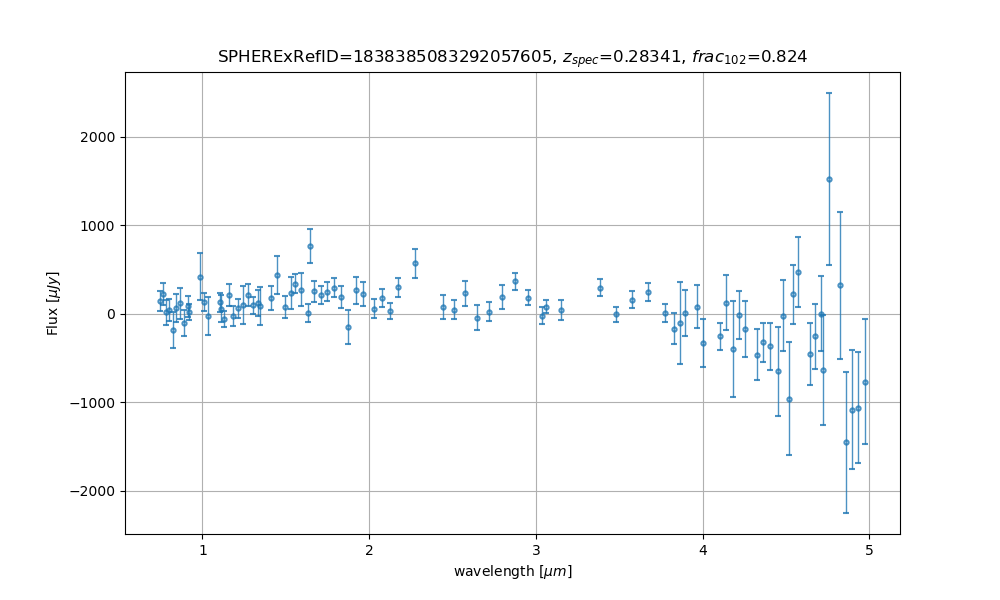

In [4]:
idx = 0

sid = dat['SPHERExRefID'].iloc[idx]
lbs = dat['lambda_fiducial'].iloc[idx]
spec = dat['flux_dered_fiducial'].iloc[idx]
err = dat['flux_err_dered_fiducial'].iloc[idx]
zspec = dat['z_specz'].iloc[idx]
frac306 = dat['frac_sampled_306'].iloc[idx]
frac102 = dat['frac_sampled_102'].iloc[idx]

nonzeros = err != 50000.0

plt.close()
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(lbs[nonzeros], spec[nonzeros], err[nonzeros], fmt='o', elinewidth=1, markersize=3, markerfacecolor='none', markeredgewidth=1.5 , capsize=2, alpha=0.8)
ax.set_xlabel(r'wavelength [$\mu m$]')
ax.set_ylabel(r'Flux [$\mu Jy$]')
ax.set_title(fr'SPHERExRefID={sid}, $z_{{spec}}$={zspec:.5f}, $frac_{{102}}$={frac102:.3f}')
ax.grid()

We could do some selection by calculating SNR of each band, by converting nested pandas columns to numpy array. I personally like to use l2-norm of flux/err vectors to estimate culmulative SNR of each object, although this definition depends on number of filters can only use in a relative sense.  
There are many different ways to select bright objects.

In [5]:
all_spectra = np.array(dat['flux_dered_fiducial'].tolist())
all_error = np.array(dat['flux_err_dered_fiducial'].tolist())
all_y = all_spectra/all_error
ynorm = np.linalg.norm(all_y, axis=1)
ynorm

array([13.76997656,  9.99954778, 15.32449854, ..., 11.13355527,
       31.07997973, 19.24311759], shape=(277181,))

(0.0, 200.0)

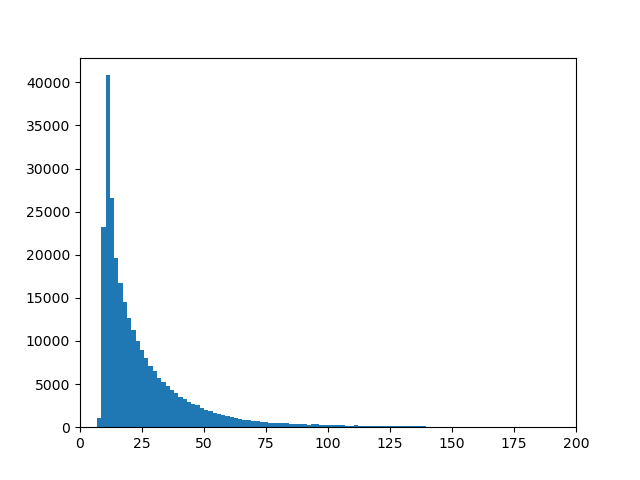

In [6]:
plt.close()
fig, ax = plt.subplots()
ax.hist(ynorm, bins=1000)
ax.set_xlim(0, 200)

The data also includes 102 fiducial fluxes, which might be useful for us,  
though we need to read the wavelength of 102 fiducial wavelength from elsewhere, namely `SPHEREx_102/fiducial_filters_cent_waves.txt`

In [7]:
filter_central_wavelengths = '/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/FILTER/SPHEREx_102/fiducial_filters_cent_waves.txt'
# central_wavelengths_tab = np.loadtxt(filter_central_wavelengths, dtype={'names': ('filter','wavelengths'), 'formats': ('U25','f8')})
lbs_102 = np.genfromtxt(filter_central_wavelengths, delimiter=' ')[:,1]


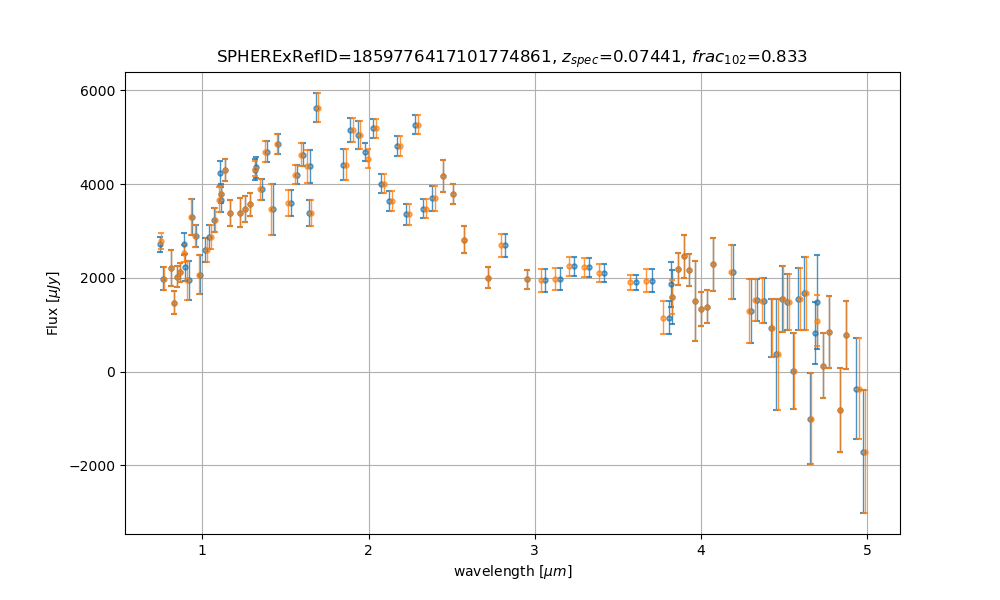

In [8]:
ynorm_mask = ynorm > 100 # pick some number

idx = 0
sid = dat['SPHERExRefID'][ynorm_mask].iloc[idx]
lbs = dat['lambda_fiducial'][ynorm_mask].iloc[idx]
spec = dat['flux_dered_fiducial'][ynorm_mask].iloc[idx]
err = dat['flux_err_dered_fiducial'][ynorm_mask].iloc[idx]
spec_102 = dat['fiducial_flux'][ynorm_mask].iloc[idx]
err_102 = dat['fiducial_flux_err'][ynorm_mask].iloc[idx]

zspec = dat['z_specz'][ynorm_mask].iloc[idx]
frac306 = dat['frac_sampled_306'][ynorm_mask].iloc[idx]
frac102 = dat['frac_sampled_102'][ynorm_mask].iloc[idx]

nonzeros = err != 50000.0
nonzeros_102 = err_102 != 50000.0

plt.close()
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(lbs[nonzeros], spec[nonzeros], err[nonzeros], fmt='o', elinewidth=1, markersize=3, markerfacecolor='none', markeredgewidth=1.5 , capsize=2, alpha=0.8)
ax.errorbar(lbs_102[nonzeros_102], spec_102[nonzeros_102], err_102[nonzeros_102], fmt='o', elinewidth=1, markersize=3, markerfacecolor='none', markeredgewidth=1.5 , capsize=2, alpha=0.8)

ax.set_xlabel(r'wavelength [$\mu m$]')
ax.set_ylabel(r'Flux [$\mu Jy$]')
ax.set_title(fr'SPHERExRefID={sid}, $z_{{spec}}$={zspec:.5f}, $frac_{{102}}$={frac102:.3f}')
ax.grid()


Text(0.5, 0, 'z_spec')

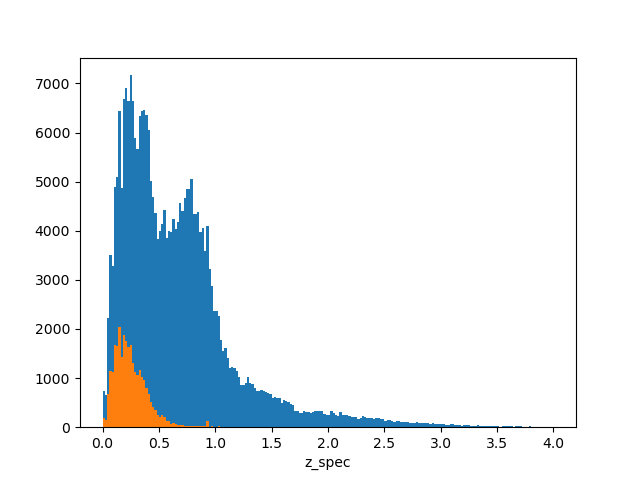

In [9]:
zspecs = dat['z_specz']
plt.close()
fig, ax = plt.subplots()
ax.hist(zspecs, bins=200, range=(0, 4))
ax.hist(zspecs[ynorm>50], bins=200, range=(0, 4))
ax.set_xlabel('z_spec')
# ax.set_ylabel('ynorm')